# Eco-Pack Presov

In [13]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Import

In [ ]:
import datetime as dt
import itertools
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from river import utils
from river.proba import Gaussian

sys.path.insert(1, str(Path.cwd().parent))
from functions.anomaly import ConditionalGaussianScorer, GaussianScorer
from functions.evaluate import progressive_val_predict
from functions.proba import MultivariateGaussian
from publications.ilustrate.pc2023.plot_matplotlib import plot_limits_grid_

### Load

In [25]:
df = pd.read_csv(
    "data/etf-energochem/anomalies-etf-2023-data.csv",
    index_col=0,
)
df.index = pd.to_datetime(df.index, utc=True)
df = df.sort_index()

In [26]:
ser_gt = pd.read_csv(
    "data/kokam/kokam_ground_truth.csv",
    index_col=0,
)["F_Module Fan Fault"]
ser_gt.index = pd.to_datetime(ser_gt.index, utc=True)

### Train and Evaluate Detection

In [52]:
# CONSTANTS
days = 28
WINDOW = dt.timedelta(hours=24 * days)
minutes = int(WINDOW.total_seconds() / 60)
GRACE_PERIOD = dt.timedelta(seconds=48 * 60 / 2)
THRESHOLD = 0.99994

model = ConditionalGaussianScorer(
    utils.TimeRolling(MultivariateGaussian(), period=WINDOW),
    grace_period=GRACE_PERIOD,
    t_a=int(minutes),
    threshold=THRESHOLD,
)

sampling_model = GaussianScorer(Gaussian(), protect_anomaly_detector=False)

system_anomaly, meta = progressive_val_predict(
    model=model,
    dataset=df,
    compute_limits=True,
    detect_signal=True,
    detect_change=True,
    sampling_model=sampling_model,
)

df_out = pd.DataFrame(
    {"System Anomaly": system_anomaly, **meta}, index=df.index,
)

Avg. latency per sample: 5.7582535677486ms


In [53]:
events_count = sum(pd.Series(system_anomaly).diff().dropna() == 1)
text = (
    f"Sliding window: {WINDOW}\n"
    f"Proportion of anomalous samples: "
    f"{sum(system_anomaly) / len(system_anomaly) * 100:.02f}%\n"
    f"Anomaly every: "
    f"{len(system_anomaly) / sum(system_anomaly):.00f} samples\n"
    f"Total number of anomalous events: "
    f"{events_count}\n"
    f"Anomalous event every: "
    f"{len(system_anomaly) / events_count:.00f} samples\n"
    f"Total number of change points: "
    f"{sum(df_out['Changepoint'].diff().dropna() == 1)}\n"
    f"Total number of sampling anomalies: "
    f"{sum(df_out['Sampling Anomaly'].diff().dropna() == 1)}"
)


Sliding window: 28 days, 0:00:00
Proportion of anomalous samples: 25.86%
Anomaly every: 4 samples
Total number of anomalous events: 443
Anomalous event every: 26 samples
Total number of change points: 0
Total number of sampling anomalies: 1


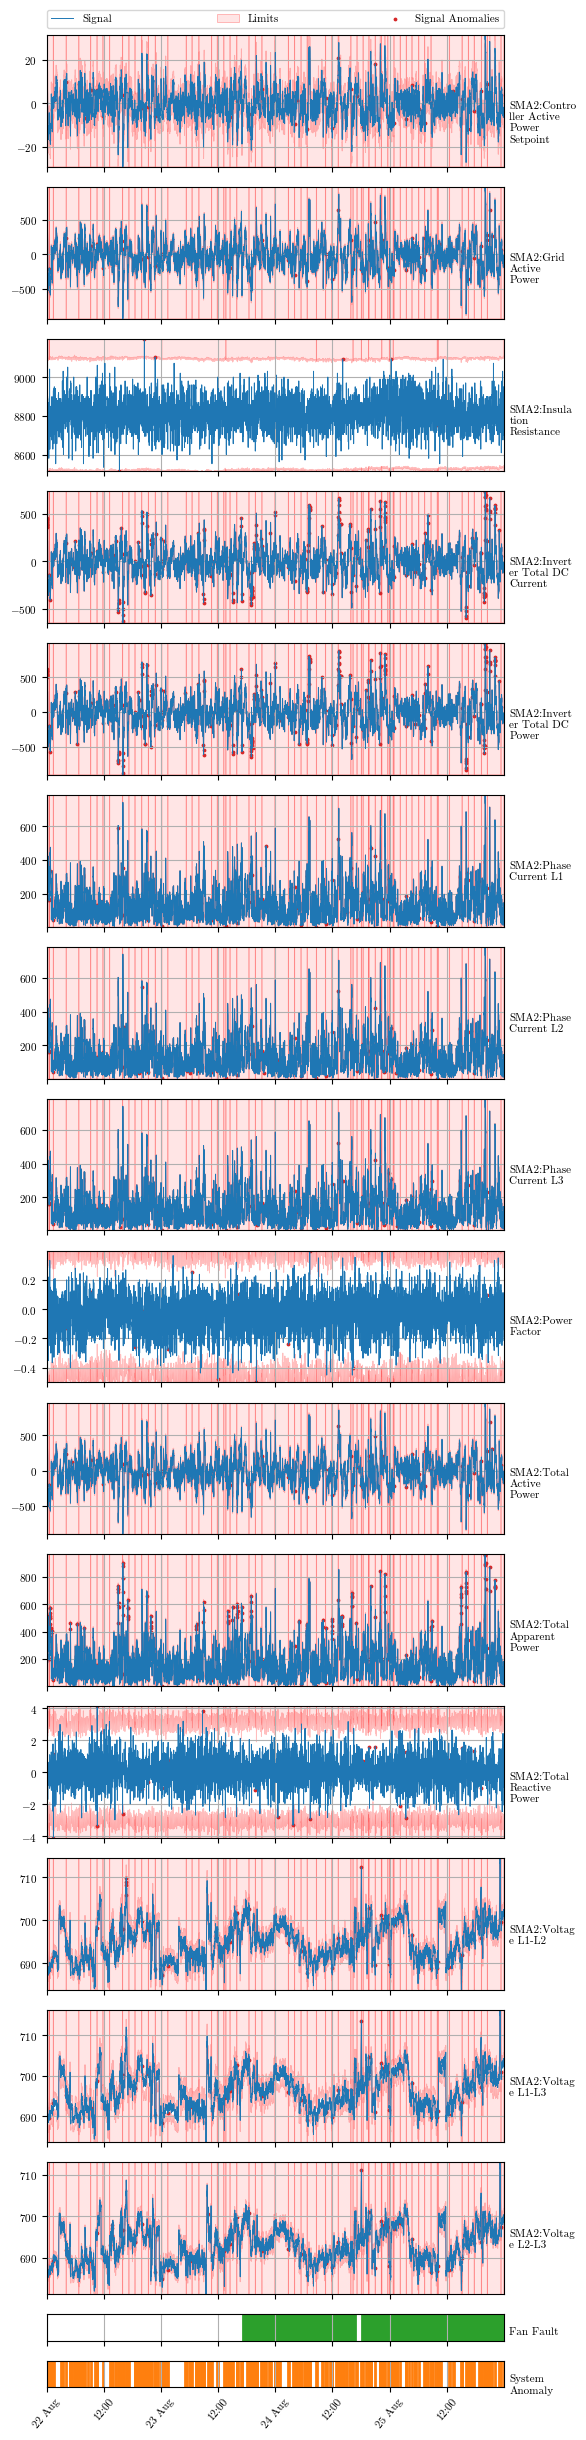

In [69]:
plot_limits_grid_(
    df.loc["2023-08-22":"2023-08-25"],
    df_out["System Anomaly"].loc["2023-08-22":"2023-08-25"],
    ser_gt.rename("Fan Fault").loc["2023-08-22":"2023-08-25"],
    ser_high=df_out["Limit High"].loc["2023-08-22":"2023-08-25"],
    ser_low=df_out["Limit Low"].loc["2023-08-22":"2023-08-25"],
    signal_anomaly=df_out["Signal Anomaly"].loc["2023-08-22":"2023-08-25"],
    file_name="Kokam_first",
    save=True,
    resample="30s",
)

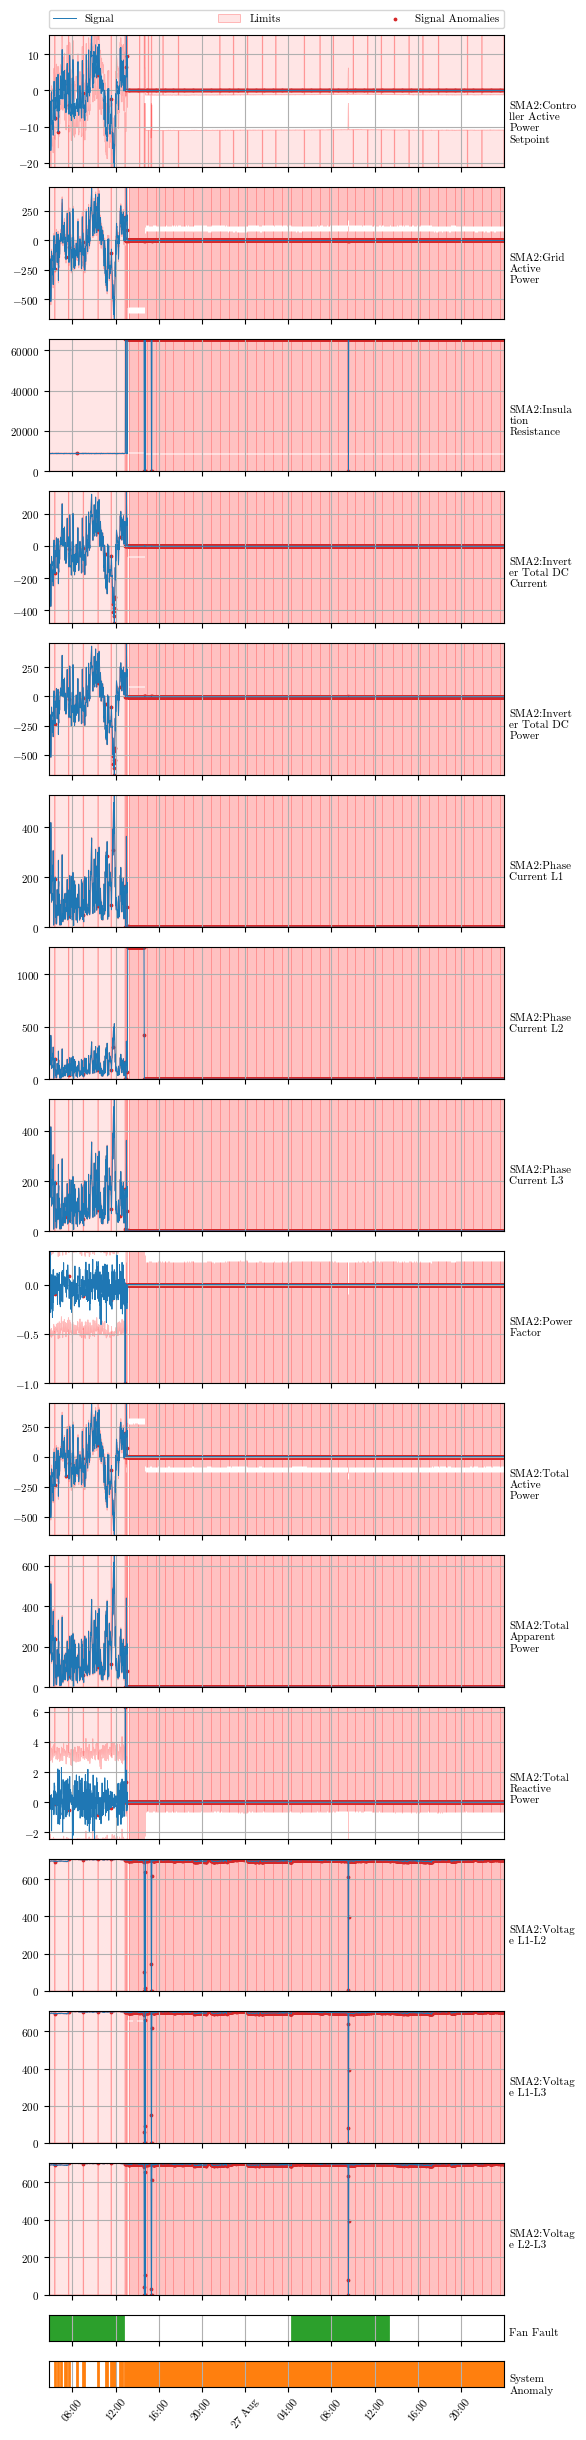

In [74]:
plot_limits_grid_(
    df.loc["2023-08-26 5:50":],
    df_out["System Anomaly"].loc["2023-08-26 5:50":],
    ser_gt.rename("Fan Fault").loc["2023-08-26 5:50":],
    ser_high=df_out["Limit High"].loc["2023-08-26 5:50":],
    ser_low=df_out["Limit Low"].loc["2023-08-26 5:50":],
    signal_anomaly=df_out["Signal Anomaly"].loc["2023-08-26 5:50":],
    file_name="Kokam_second",
    save=True,
    resample="30s",
)

# Using Previous Knowledge

In [75]:
X_arr = df.values
mean_arr = X_arr.mean(axis=0)
cov_arr = np.cov(X_arr.T, ddof=1)

mean = dict(zip(df.columns, mean_arr, strict=False))
cov = {
    (i, j): cov_arr[r, c]
    for (r, i), (c, j) in itertools.combinations_with_replacement(
        enumerate(df.columns), r=2,
    )
}

In [76]:
# CONSTANTS
days = 28
WINDOW = dt.timedelta(hours=24 * days)
minutes = int(WINDOW.total_seconds() / 60)
GRACE_PERIOD = dt.timedelta(minutes=48 * 60)
THRESHOLD = 0.99994

model = ConditionalGaussianScorer(
    utils.TimeRolling(
        MultivariateGaussian._from_state(1000, mean, cov, ddof=1, seed=42),
        period=WINDOW,
    ),
    grace_period=GRACE_PERIOD,
    t_a=int(minutes),
    threshold=THRESHOLD,
)

sampling_model = GaussianScorer(Gaussian(), protect_anomaly_detector=False)

system_anomaly, meta = progressive_val_predict(
    model=model,
    dataset=df,
    compute_limits=True,
    detect_signal=True,
    detect_change=True,
    sampling_model=sampling_model,
)

df_out = pd.DataFrame(
    {"System Anomaly": system_anomaly, **meta}, index=df.index,
)

Avg. latency per sample: 4.485599241322941ms


In [77]:
events_count = sum(pd.Series(system_anomaly).diff().dropna() == 1)
text = (
    f"Sliding window: {WINDOW}\n"
    f"Proportion of anomalous samples: "
    f"{sum(system_anomaly) / len(system_anomaly) * 100:.02f}%\n"
    f"Anomaly every: "
    f"{len(system_anomaly) / sum(system_anomaly):.00f} samples\n"
    f"Total number of anomalous events: "
    f"{events_count}\n"
    f"Anomalous event every: "
    f"{len(system_anomaly) / events_count:.00f} samples\n"
    f"Total number of change points: "
    f"{sum(df_out['Changepoint'].diff().dropna() == 1)}\n"
    f"Total number of sampling anomalies: "
    f"{sum(df_out['Sampling Anomaly'].diff().dropna() == 1)}"
)


Sliding window: 28 days, 0:00:00
Proportion of anomalous samples: 74.98%
Anomaly every: 1 samples
Total number of anomalous events: 1
Anomalous event every: 11520 samples
Total number of change points: 0
Total number of sampling anomalies: 1


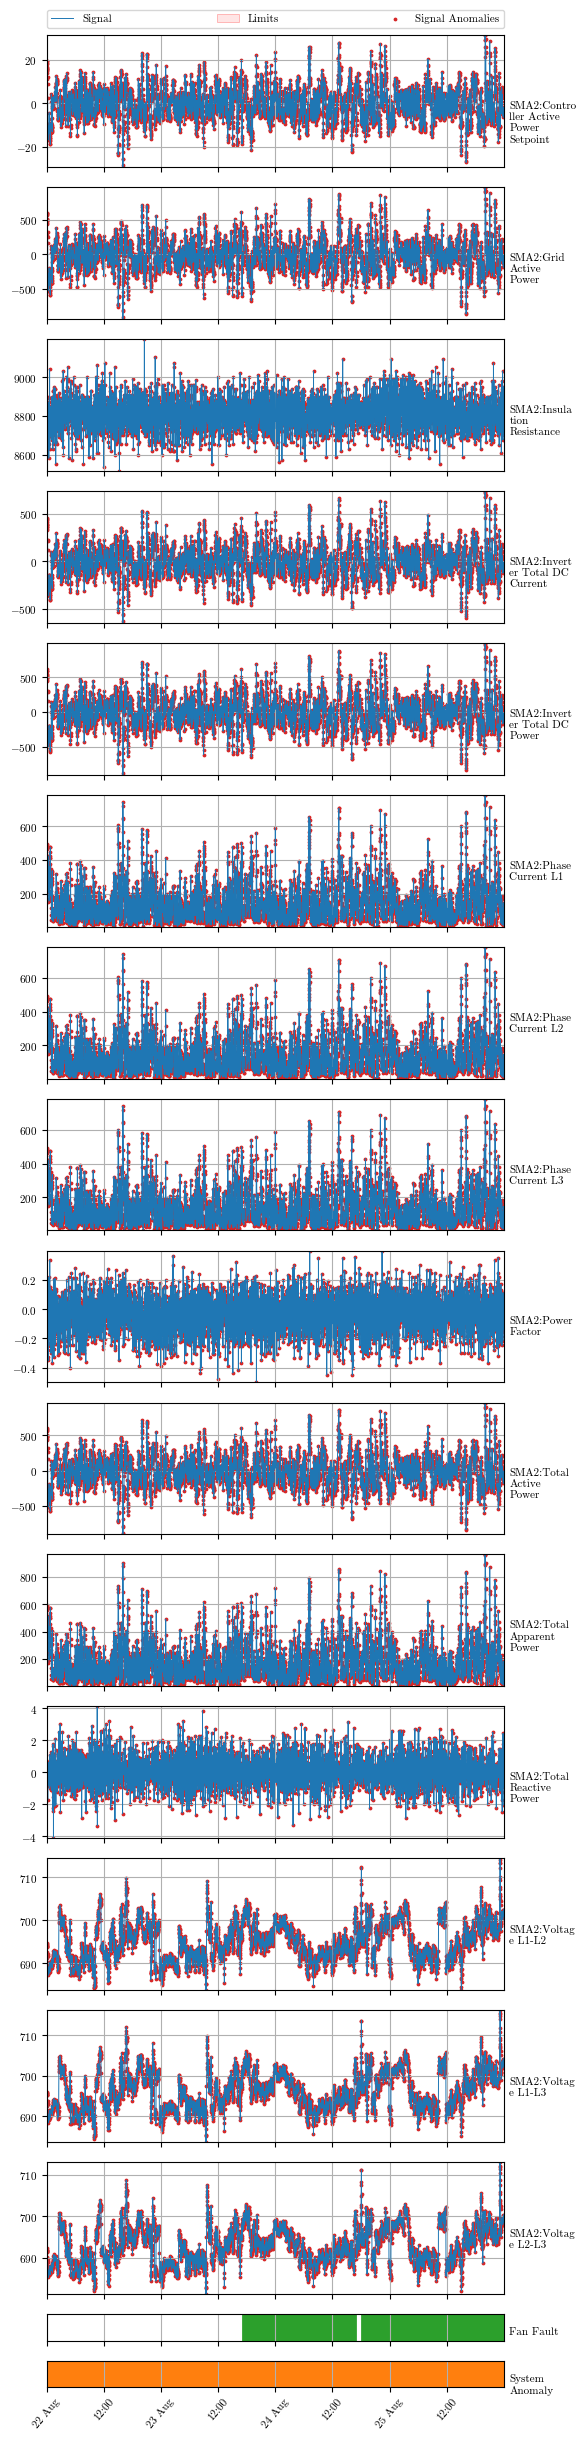

In [78]:
plot_limits_grid_(
    df.loc["2023-08-22":"2023-08-25"],
    df_out["System Anomaly"].loc["2023-08-22":"2023-08-25"],
    ser_gt.rename("Fan Fault").loc["2023-08-22":"2023-08-25"],
    ser_high=df_out["Limit High"].loc["2023-08-22":"2023-08-25"],
    ser_low=df_out["Limit Low"].loc["2023-08-22":"2023-08-25"],
    signal_anomaly=df_out["Signal Anomaly"].loc["2023-08-22":"2023-08-25"],
    file_name="Kokam_first",
    save=False,
    resample="30s",
)

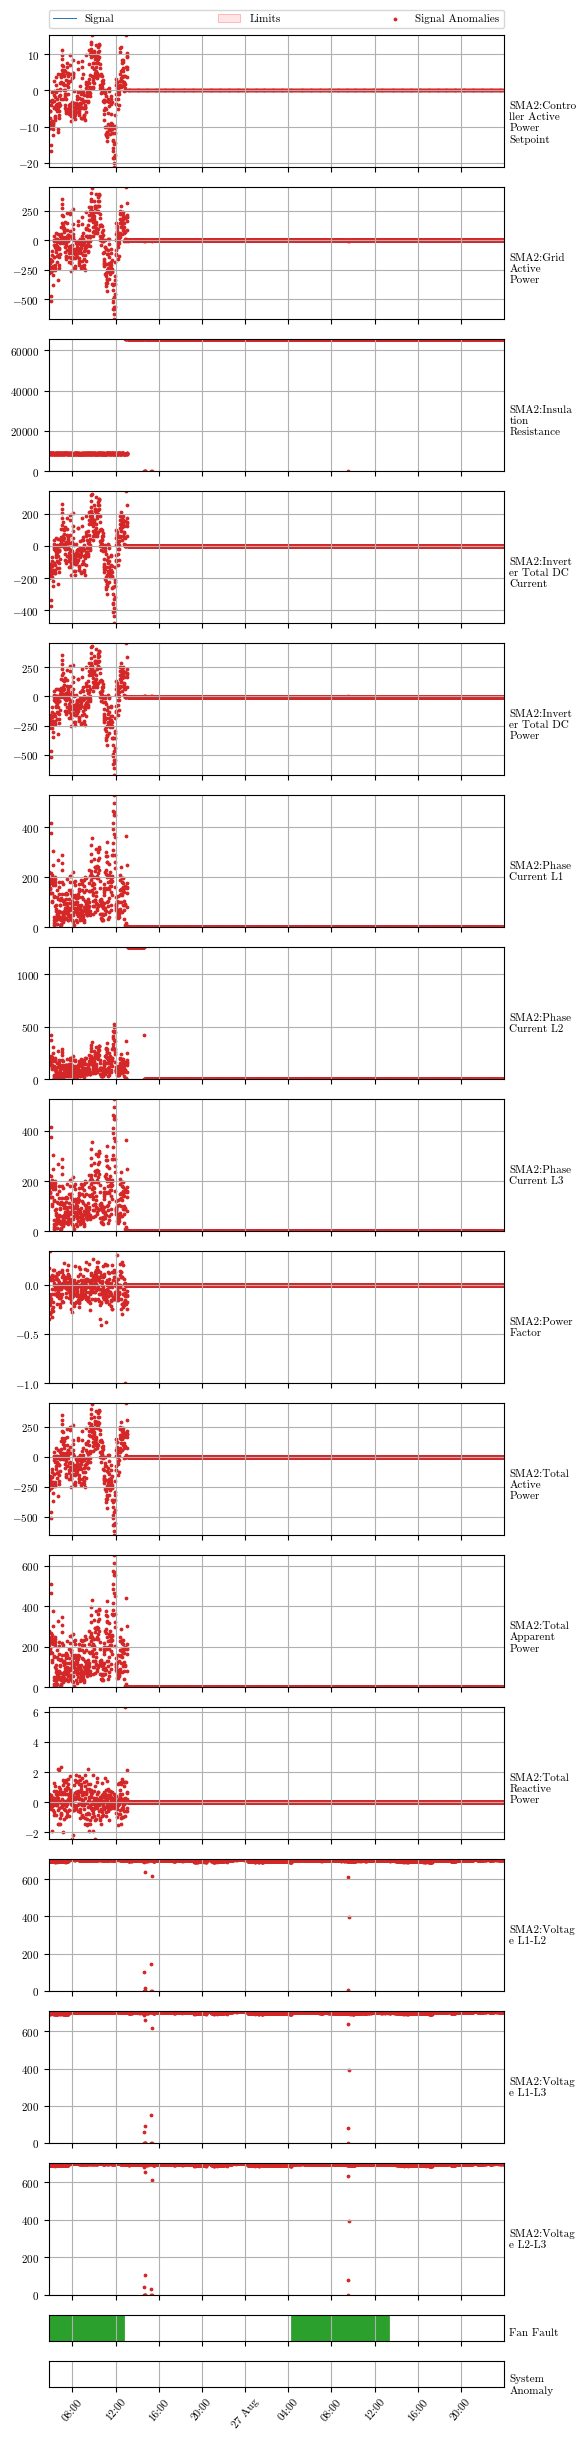

In [47]:
plot_limits_grid_(
    df.loc["2023-08-26 5:50":],
    df_out["System Anomaly"].loc["2023-08-26 5:50":],
    ser_gt.rename("Fan Fault").loc["2023-08-26 5:50":],
    ser_high=df_out["Limit High"].loc["2023-08-26 5:50":],
    ser_low=df_out["Limit Low"].loc["2023-08-26 5:50":],
    signal_anomaly=df_out["Signal Anomaly"].loc["2023-08-26 5:50":],
    file_name="Kokam_second",
    save=False,
    resample="30s",
)